In [9]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import norm

In [12]:
def plot_timing():

    multi = np.load("timing_test_multitrial.npz", allow_pickle=True)
    single = np.load("timing_test.npz", allow_pickle=True)

    summary = multi["timing_summary"]

    N = []
    acq = []
    off = []
    acq_std = []
    off_std = []

    for s in summary:
        N.append(s["N_accum"])
        acq.append(s["acq_mean"])
        off.append(s["off_mean"])
        acq_std.append(s["acq_std"])
        off_std.append(s["off_std"])

    plt.figure(figsize=(6,5))

    plt.errorbar(N, acq, yerr=acq_std, marker="o", label="Acquisition")
    plt.errorbar(N, off, yerr=off_std, marker="o", label="Offload")

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel("N_accum")
    plt.ylabel("Time (s)")
    plt.title("Acquisition / Offload Scaling")

    plt.legend()
    plt.grid(True, which="both")
    plt.show()

In [11]:
def load_hop_data():

    files = sorted(glob.glob("hop_span*.npz"))

    spectra = []
    counts = []
    flags = []
    lo = []

    for f in files:

        d = np.load(f, allow_pickle=True)

        spectra.append(d["avg"])
        counts.append(d["bin_counts"])
        flags.append(d["flagged_bins"])
        lo.append(d["lo_history"])

    spectra = np.array(spectra)
    counts = np.array(counts)

    return spectra, counts, flags, lo

In [13]:
def load_hop_data():

    files = sorted(glob.glob("hop_span*.npz"))

    spectra = []
    counts = []
    flags = []
    lo = []

    for f in files:

        d = np.load(f, allow_pickle=True)

        spectra.append(d["avg"])
        counts.append(d["bin_counts"])
        flags.append(d["flagged_bins"])
        lo.append(d["lo_history"])

    spectra = np.array(spectra)
    counts = np.array(counts)

    return spectra, counts, flags, lo

In [14]:
def plot_spectra(spectra):

    plt.figure(figsize=(8,5))

    for s in spectra:
        plt.plot(s, alpha=0.7)

    plt.xlabel("FFT Bin")
    plt.ylabel("Power")
    plt.title("Spectra vs Hopping Coverage")

    plt.show()

In [15]:
def build_freq_axis(spec_len, fs):

    return np.linspace(0, fs, spec_len)

In [16]:
WINDOW = 50
N_WINDOWS = 6
POLY_ORDER = 3


def analyze_windows(F, spectra):

    fmin = F.min()
    fmax = F.max() - WINDOW

    starts = np.random.uniform(fmin, fmax, N_WINDOWS)

    for start in starts:

        stop = start + WINDOW

        mask = (F >= start) & (F <= stop)

        Fw = F[mask]
        Sw = spectra[:, mask]

        residuals = np.zeros_like(Sw)

        x = np.arange(Sw.shape[1])

        for i,row in enumerate(Sw):

            p = np.polyfit(x,row,POLY_ORDER)
            base = np.polyval(p,x)

            residuals[i] = row-base

        fig,axes = plt.subplots(2,2,figsize=(10,8))

        for r in Sw:
            axes[0,0].plot(Fw,r,alpha=0.3)

        axes[0,0].set_title("Raw Spectra")

        for r in residuals:
            axes[0,1].plot(Fw,r,alpha=0.3)

        axes[0,1].set_title("Baseline Removed")

        sigma = np.std(residuals,axis=1)
        t = np.arange(1,len(sigma)+1)

        axes[1,0].loglog(t,sigma,'o')

        ref = sigma[0]*(t/t[0])**(-0.5)
        axes[1,0].loglog(t,ref,'--')

        axes[1,0].set_title("Radiometer Test")

        flat = residuals.flatten()
        mu,std = np.mean(flat),np.std(flat)

        axes[1,1].hist(flat,bins=70,density=True)

        xg = np.linspace(mu-5*std,mu+5*std,400)
        axes[1,1].plot(xg,norm.pdf(xg,mu,std),'r')

        axes[1,1].set_title("Gaussian Test")

        plt.suptitle(f"{start:.1f}-{stop:.1f} MHz Window")

        plt.tight_layout()
        plt.show()

In [17]:
def plot_rfi(flags):

    flags = np.array(flags)

    combined = np.any(flags,axis=0)

    plt.figure(figsize=(8,3))

    plt.plot(combined.astype(int))

    plt.xlabel("FFT Bin")
    plt.ylabel("Flag")

    plt.title("RFI Flagged Bins")

    plt.show()

    pct = 100*np.sum(combined)/len(combined)

    print("Percent bins flagged:",pct)

In [18]:
def plot_rfi_frequency(flags,F):

    combined = np.any(flags,axis=0)

    plt.figure(figsize=(8,4))

    plt.plot(F,combined.astype(int))

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Flag")

    plt.title("RFI vs Frequency")

    plt.show()

In [19]:
def check_overflow(spectra):

    if np.any(spectra < 0):
        print("WARNING: Negative values detected (possible overflow)")
    else:
        print("No negative values detected")

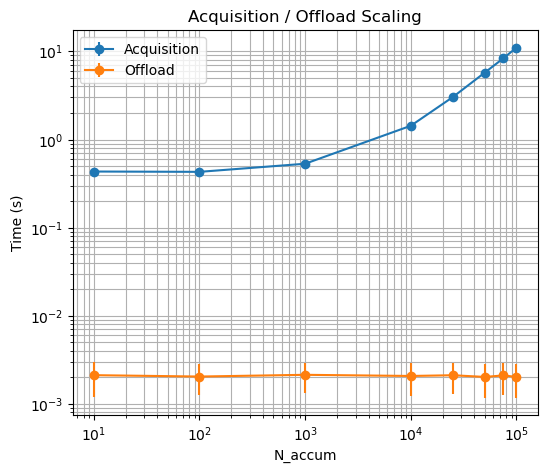

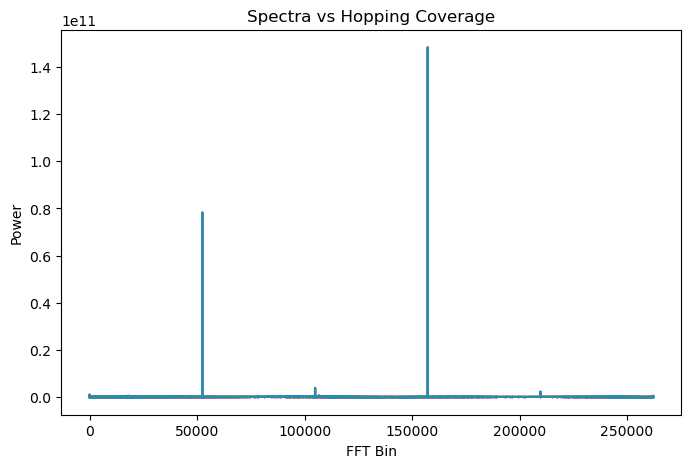

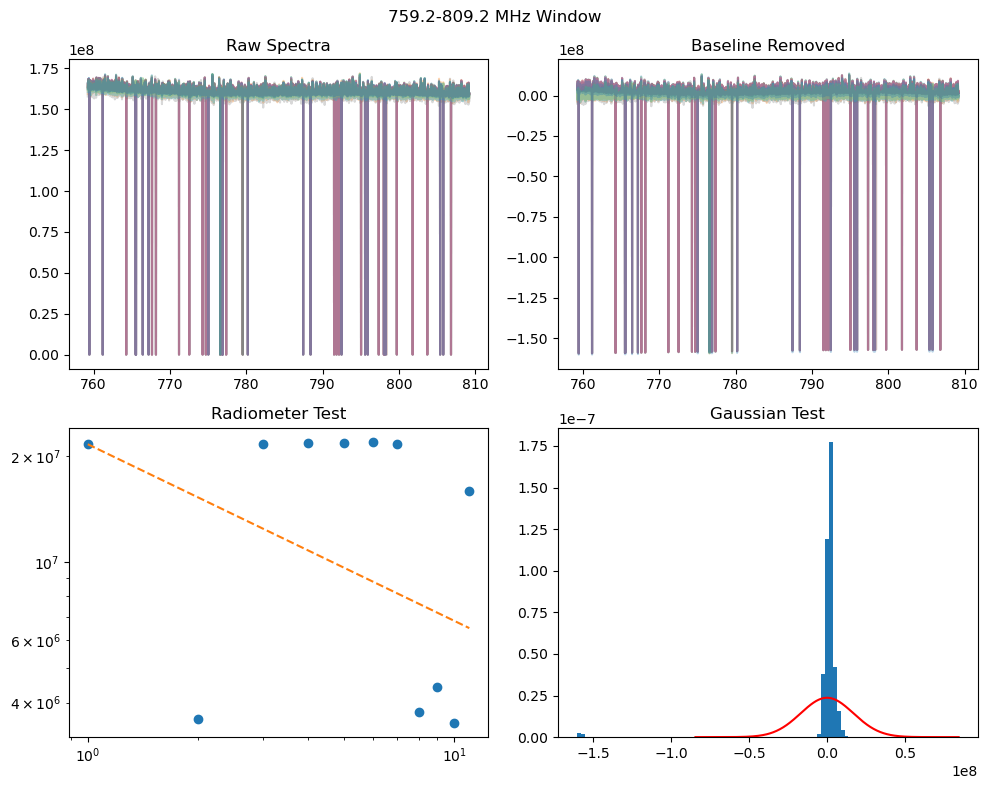

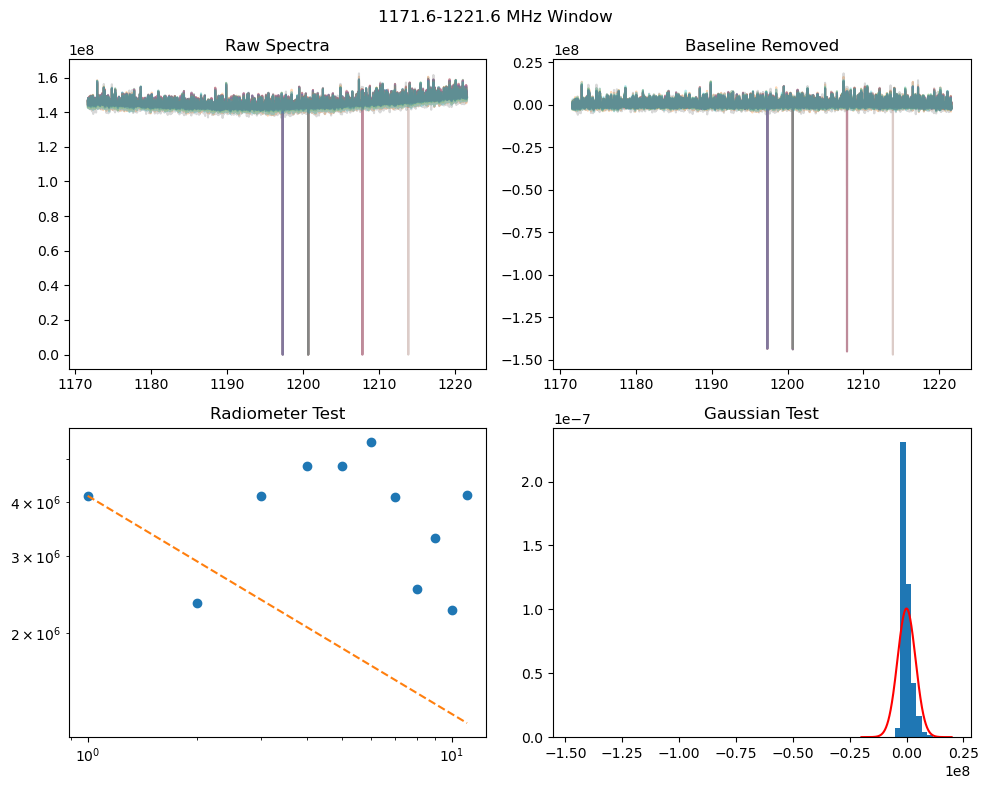

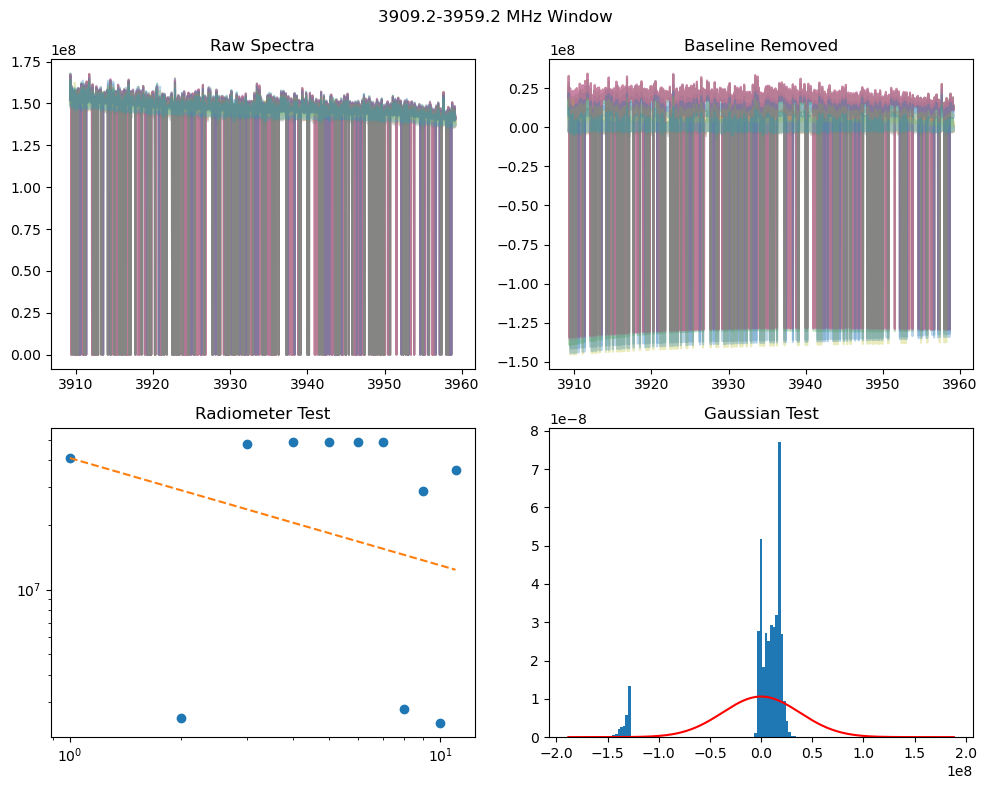

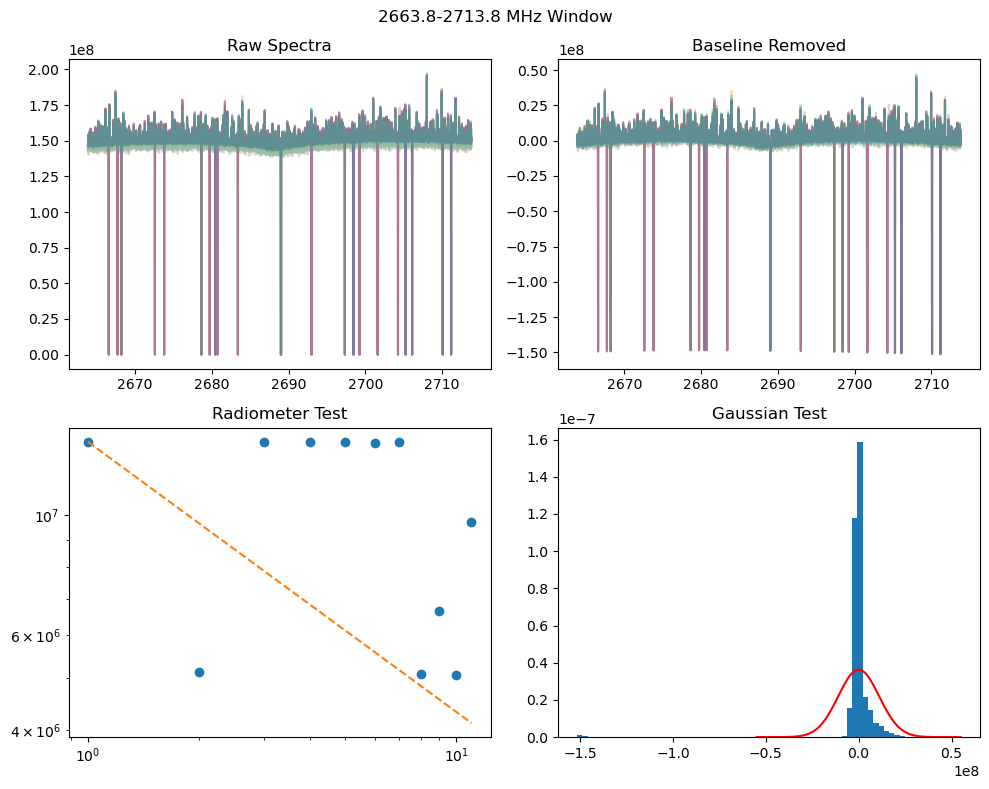

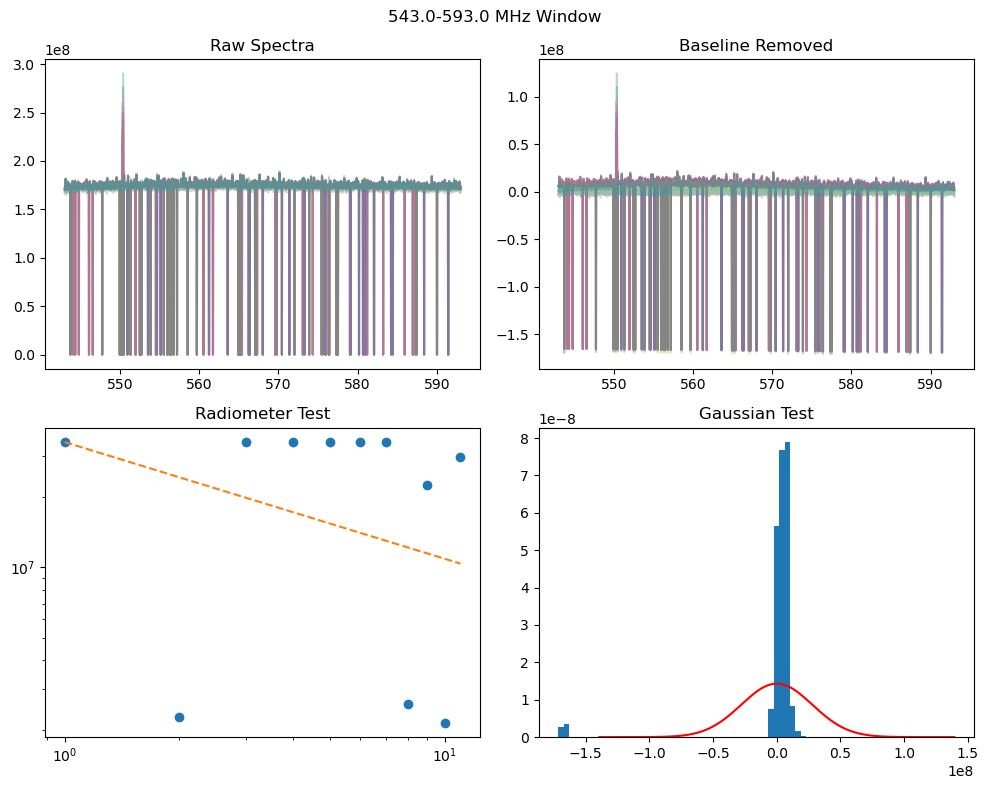

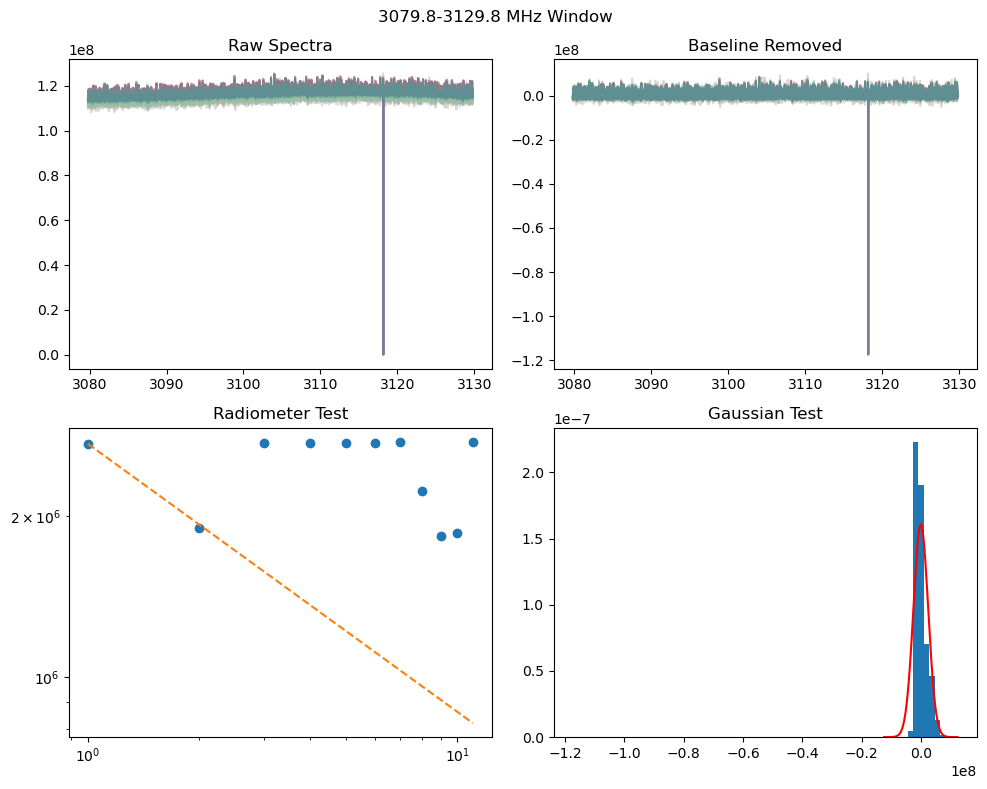

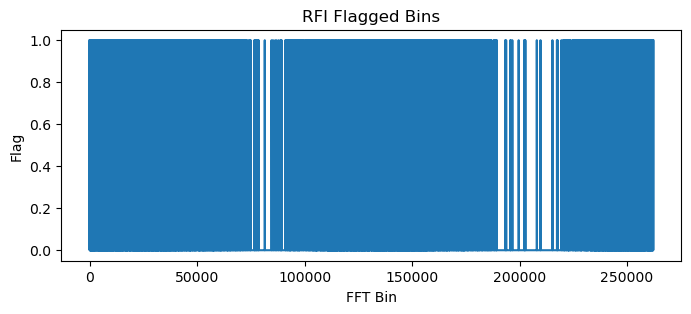

Percent bins flagged: 4.1522979736328125


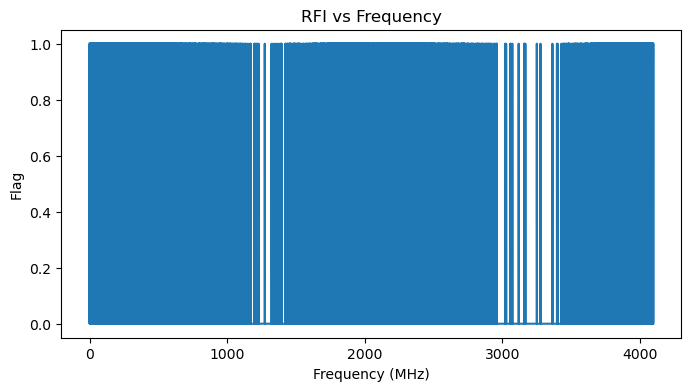

No negative values detected


In [20]:
plot_timing()

spectra,counts,flags,lo = load_hop_data()

plot_spectra(spectra)

spec_len = spectra.shape[1]
F = build_freq_axis(spec_len,4096)

analyze_windows(F,spectra)

plot_rfi(flags)

plot_rfi_frequency(flags,F)

check_overflow(spectra)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def plot_rfi_overlay(F, spectra, flags):

    flags = np.array(flags)

    flag_rate = np.mean(flags, axis=0)

    avg_spec = np.mean(spectra, axis=0)

    fig, ax = plt.subplots(figsize=(10,4))

    norm = Normalize(vmin=0, vmax=np.max(flag_rate))

    cmap = plt.cm.Reds

    for i in range(len(F)-1):

        if flag_rate[i] > 0:

            ax.axvspan(
                F[i],
                F[i+1],
                color=cmap(norm(flag_rate[i])),
                alpha=0.35
            )

    for s in spectra:
        ax.plot(F, s, alpha=0.3)

    ax.plot(F, avg_spec, color="black", linewidth=2, label="Average")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("RFI Flag Frequency")

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Power [ADU^2]")

    ax.set_title("Spectrum with RFI Flagging Overlay")

    ax.legend()

    plt.show()

/opt/anaconda3/envs/stenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


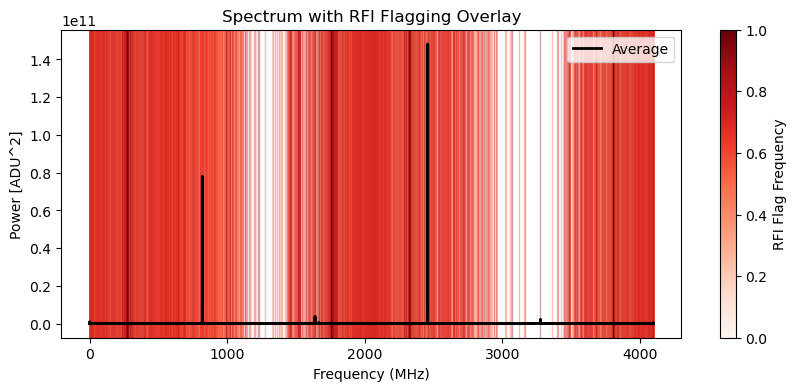

In [26]:
plot_rfi_overlay(F, spectra, flags)

In [23]:
import numpy as np

def check_overflow_global(spectra):

    neg = spectra < 0

    if np.any(neg):
        print("Overflow detected")
        print("Total negative samples:", np.sum(neg))
    else:
        print("No negative values detected")

In [24]:
check_overflow_global(spectra)

No negative values detected


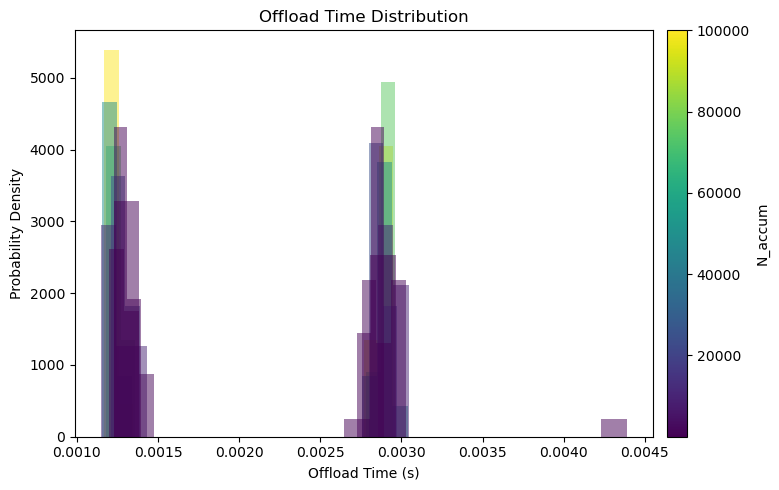

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

def plot_timing():

    multi = np.load("timing_test_multitrial.npz", allow_pickle=True)

    trials = multi["timing_trials"]

    N_vals = sorted(list(set([t["N_accum"] for t in trials])))

    cmap = cm.viridis
    norm = Normalize(vmin=min(N_vals), vmax=max(N_vals))

    fig, ax = plt.subplots(figsize=(8,5))

    for N in sorted(N_vals, reverse=True):

        off = [t["offload_time"] for t in trials if t["N_accum"] == N]

        color = cmap(norm(N))

        ax.hist(
            off,
            bins=20,
            alpha=0.5,
            color=color,
            density=True
        )

    ax.set_xlabel("Offload Time (s)")
    ax.set_ylabel("Probability Density")
    ax.set_title("Offload Time Distribution")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("N_accum")

    plt.tight_layout()
    plt.show()

plot_timing()

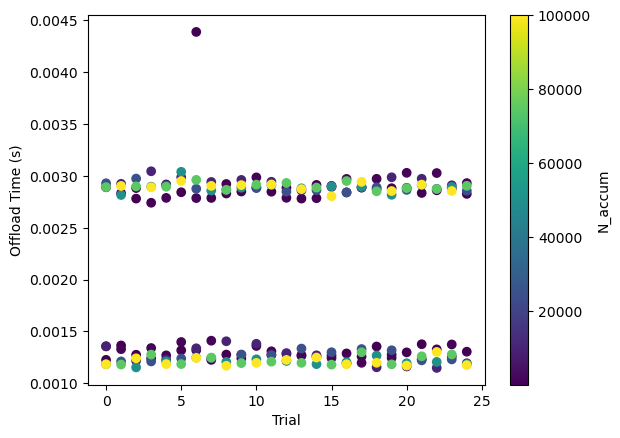

In [35]:
import numpy as np
import matplotlib.pyplot as plt

multi = np.load("timing_test_multitrial.npz", allow_pickle=True)
trials = multi["timing_trials"]

plt.scatter(
    [t["trial"] for t in trials],
    [t["offload_time"] for t in trials],
    c=[t["N_accum"] for t in trials]
)

plt.xlabel("Trial")
plt.ylabel("Offload Time (s)")
plt.colorbar(label="N_accum")
plt.show()

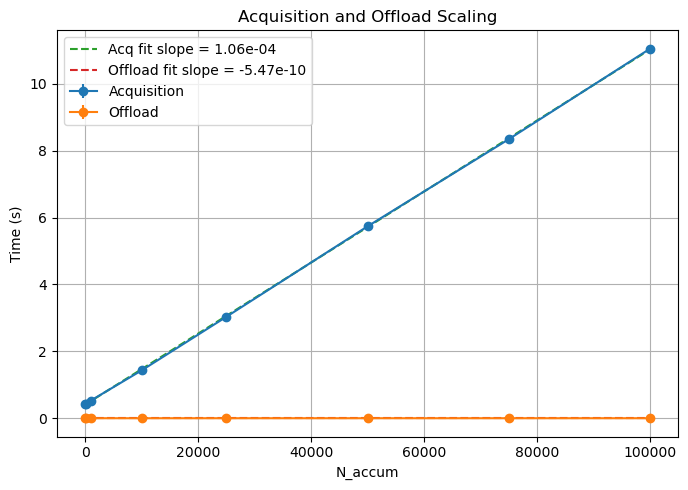

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def plot_timing():

    multi = np.load("timing_test_multitrial.npz", allow_pickle=True)
    summary = multi["timing_summary"]

    N = np.array([s["N_accum"] for s in summary])
    acq_mean = np.array([s["acq_mean"] for s in summary])
    off_mean = np.array([s["off_mean"] for s in summary])
    acq_std = np.array([s["acq_std"] for s in summary])
    off_std = np.array([s["off_std"] for s in summary])

    fit_acq = np.polyfit(N, acq_mean, 1)
    fit_off = np.polyfit(N, off_mean, 1)

    xfit = np.linspace(min(N), max(N), 200)

    plt.figure(figsize=(7,5))

    plt.errorbar(N, acq_mean, yerr=acq_std, marker="o", label="Acquisition")
    plt.errorbar(N, off_mean, yerr=off_std, marker="o", label="Offload")

    plt.plot(xfit, np.polyval(fit_acq, xfit), "--", label=f"Acq fit slope = {fit_acq[0]:.2e}")
    plt.plot(xfit, np.polyval(fit_off, xfit), "--", label=f"Offload fit slope = {fit_off[0]:.2e}")

    plt.xlabel("N_accum")
    plt.ylabel("Time (s)")
    plt.title("Acquisition and Offload Scaling")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_timing()

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.animation import FuncAnimation

def animate_rfi_mask(F, spectra, flags, output="rfi_masking.mp4"):

    spectra = np.array(spectra)
    flags = np.array(flags)

    fig, ax = plt.subplots(figsize=(10,4))

    norm = Normalize(vmin=0, vmax=1)
    cmap = plt.cm.Reds

    line, = ax.plot([], [], color="black", lw=1)

    ax.set_xlim(F.min(), F.max())
    ax.set_ylim(np.min(spectra), np.max(spectra))

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Power [ADU²]")
    ax.set_title("Instantaneous Spectrum with RFI Masking")

    spans = []

    def update(frame):

        nonlocal spans

        for sp in spans:
            sp.remove()
        spans = []

        spec = spectra[frame]
        mask = flags[frame]

        line.set_data(F, spec)

        for i in range(len(F)-1):
            if mask[i]:
                sp = ax.axvspan(
                    F[i],
                    F[i+1],
                    color=cmap(norm(1)),
                    alpha=0.35
                )
                spans.append(sp)

        ax.set_title(f"Spectrum {frame+1}/{len(spectra)}")

        return [line] + spans


    anim = FuncAnimation(
        fig,
        update,
        frames=len(spectra),
        interval=50,
        blit=False
    )

    anim.save(output, dpi=150, fps=20)

    print(f"Saved animation → {output}")

python(45974) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved animation → rfi_masking.mp4


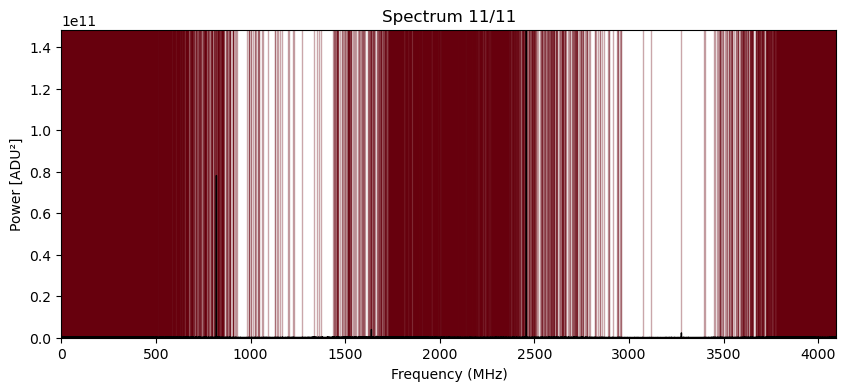

In [38]:
animate_rfi_mask(F, spectra, flags)